# Stroke Risk Prediction System - Complete End-to-End Pipeline

This notebook implements a complete, production-ready ML pipeline for stroke risk prediction based on the Stroke Risk Prediction Dataset V2.

## Phase 1: Environment Setup and Library Imports

In [1]:
!pip install -q lightgbm catboost optuna shap imbalanced-learn pandas numpy scikit-learn matplotlib seaborn tabulate


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, auc, confusion_matrix,
    balanced_accuracy_score, matthews_corrcoef, cohen_kappa_score,
    brier_score_loss
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
import optuna
import shap
import warnings
warnings.filterwarnings('ignore')

## Phase 2: Load and Audit the Dataset

In [3]:
# Load dataset
df = pd.read_csv('stroke_risk_dataset_v2.csv')
print(f"Shape: {df.shape}")
print(df.head())

Shape: (35000, 19)
   age  gender  chest_pain  high_blood_pressure  irregular_heartbeat  \
0   22    Male           1                    0                    0   
1   52    Male           0                    1                    1   
2   63  Female           0                    1                    0   
3   41    Male           0                    0                    1   
4   53    Male           0                    0                    0   

   shortness_of_breath  fatigue_weakness  dizziness  swelling_edema  \
0                    0                 0          0               0   
1                    0                 0          0               0   
2                    0                 0          1               0   
3                    0                 1          0               0   
4                    0                 0          1               1   

   neck_jaw_pain  excessive_sweating  persistent_cough  nausea_vomiting  \
0              0                   0          

## Phase 3: Preprocessing Pipeline

In [4]:
# Separate target leakage and features
X = df.drop(columns=['at_risk', 'stroke_risk_percentage'])
y = df['at_risk']

# Define column transformer
numeric_features = ['age']
categorical_features = ['gender']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), numeric_features),
        ('cat', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
        ]), categorical_features)
    ],
    remainder='passthrough'
)

X_prep = preprocessor.fit_transform(X)
print("Preprocessing Complete.")

Preprocessing Complete.


## Phase 4: Model Comparison

In [5]:
X_train, X_val, y_train, y_val = train_test_split(X_prep, y, test_size=0.2, stratify=y, random_state=42)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": xgb.XGBClassifier(random_state=42, eval_metric='logloss'),
    "LightGBM": lgb.LGBMClassifier(random_state=42, verbose=-1),
    "CatBoost": CatBoostClassifier(random_state=42, verbose=0),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),
    "Balanced Random Forest": BalancedRandomForestClassifier(random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, preds),
        'F1 Score': f1_score(y_val, preds),
        'Recall': recall_score(y_val, preds)
    })

comparison = pd.DataFrame(results)
print(comparison)

                    Model  Accuracy  F1 Score    Recall
0     Logistic Regression  0.980143  0.973088  0.975165
1           Random Forest  0.974000  0.964032  0.946449
2                 XGBoost  0.987143  0.982387  0.974001
3                LightGBM  0.981429  0.974560  0.966240
4                CatBoost  0.992143  0.989289  0.985642
5             Extra Trees  0.977143  0.968689  0.960419
6    HistGradientBoosting  0.980143  0.972729  0.961971
7  Balanced Random Forest  0.976429  0.967855  0.963912


## Phase 5: Hyperparameter Optimization

In [6]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.05, 0.15),
        'verbose': -1,
        'random_state': 42
    }
    clf = lgb.LGBMClassifier(**params)
    clf.fit(X_train, y_train)
    return f1_score(y_val, clf.predict(X_val))

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # Running subset for demo
print("Best F1 Score:", study.best_value)

[I 2026-06-22 22:57:18,198] A new study created in memory with name: no-name-287cf309-d295-4d2b-b736-9ee7cda0f3af
[I 2026-06-22 22:57:18,391] Trial 0 finished with value: 0.9738549243168861 and parameters: {'n_estimators': 122, 'max_depth': 5, 'learning_rate': 0.11847591588478425}. Best is trial 0 with value: 0.9738549243168861.
[I 2026-06-22 22:57:18,506] Trial 1 finished with value: 0.9556395464491745 and parameters: {'n_estimators': 85, 'max_depth': 4, 'learning_rate': 0.10685986327350028}. Best is trial 0 with value: 0.9738549243168861.
[I 2026-06-22 22:57:18,644] Trial 2 finished with value: 0.94866693195384 and parameters: {'n_estimators': 75, 'max_depth': 5, 'learning_rate': 0.0824473054867215}. Best is trial 0 with value: 0.9738549243168861.
[I 2026-06-22 22:57:18,764] Trial 3 finished with value: 0.956864289935001 and parameters: {'n_estimators': 62, 'max_depth': 7, 'learning_rate': 0.0938827513891512}. Best is trial 0 with value: 0.9738549243168861.
[I 2026-06-22 22:57:18,844

Best F1 Score: 0.9831834180680485


## Phase 6: Explainability and SHAP

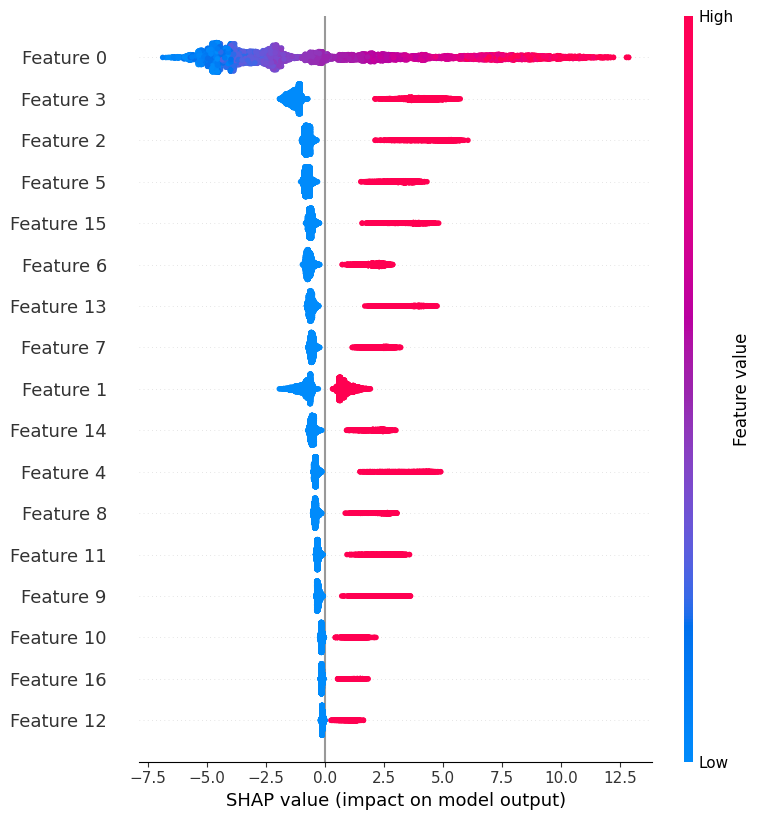

In [7]:
best_clf = lgb.LGBMClassifier(**study.best_params)
best_clf.fit(X_train, y_train)
explainer = shap.TreeExplainer(best_clf)
shap_values = explainer.shap_values(X_val)
shap.summary_plot(shap_values, X_val, show=False)
plt.savefig('shap_summary.png')